In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

In [19]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = r"C:\Users\aditi\Downloads\Solar Panel"

In [21]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 477 files belonging to 2 classes.
Using 382 files for training.
Found 477 files belonging to 2 classes.
Using 95 files for validation.
Classes: ['Clean', 'Dirty']


In [22]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [23]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomBrightness(0.15),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomTranslation(0.03,0.03),
    tf.keras.layers.RandomZoom(0.05)
])

In [24]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ MobileNetV3Small (Functional)        │ (None, 7, 7, 576)           │         939,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 576)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             577 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 939,697 (3.58 MB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [25]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

class_weight = {
    0: 1.20,   # Clean
    1: 0.86    # Dirty
}

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 913ms/step - accuracy: 0.5288 - loss: 0.7549 - val_accuracy: 0.6632 - val_loss: 0.5949
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 613ms/step - accuracy: 0.6387 - loss: 0.6562 - val_accuracy: 0.7579 - val_loss: 0.5483
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 530ms/step - accuracy: 0.6937 - loss: 0.5790 - val_accuracy: 0.7579 - val_loss: 0.5127
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 599ms/step - accuracy: 0.7513 - loss: 0.5294 - val_accuracy: 0.8316 - val_loss: 0.4743
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 527ms/step - accuracy: 0.7958 - loss: 0.4987 - val_accuracy: 0.8211 - val_loss: 0.4558
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 602ms/step - accuracy: 0.8063 - loss: 0.4518 - val_accuracy: 0.8105 - val_loss: 0.4475
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 636ms/step - accuracy: 0.8037 - loss: 0.4439 - val_accuracy: 0.8526 - val_loss: 0.4348
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 703ms/step - accuracy: 0.8168 - loss: 0.4213 - val_accuracy:

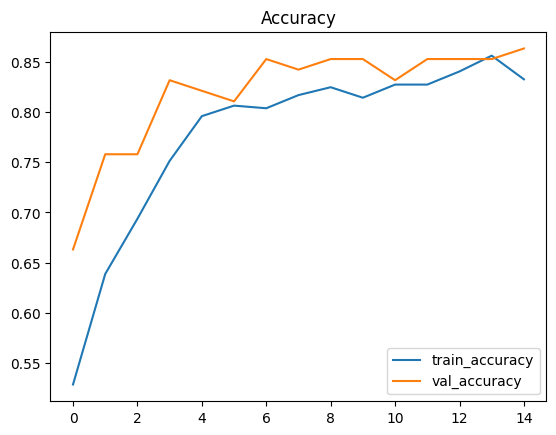

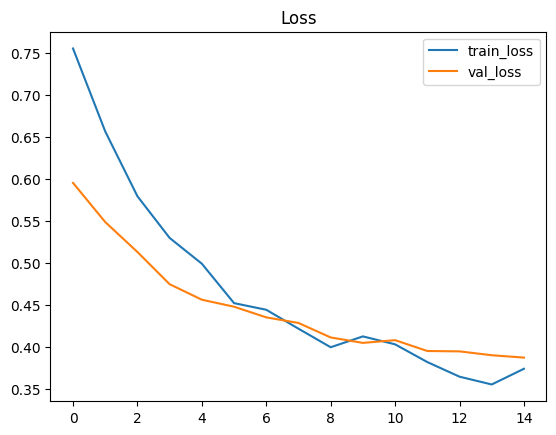

In [27]:
plt.plot(history.history['accuracy'], label="train_accuracy")
plt.plot(history.history['val_accuracy'], label="val_accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label="train_loss")
plt.plot(history.history['val_loss'], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()

In [29]:
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

y_pred = (y_pred_probs >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Confusion Matrix:
[[30  7]
 [ 6 52]]

Classification Report:
              precision    recall  f1-score   support

       Clean       0.83      0.81      0.82        37
       Dirty       0.88      0.90      0.89        58

    accuracy                           0.86        95
   macro avg       0.86      0.85      0.86        95
weighted avg       0.86      0.86      0.86        95



In [30]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

with open("solar_panel_clean_dirty_quant.tflite", "wb") as f:
    f.write(tflite_quant_model)

print("Saved: solar_panel_clean_dirty_quant.tflite")

INFO:tensorflow:Assets written to: C:\Users\aditi\AppData\Local\Temp\tmpx0kuiape\assets


INFO:tensorflow:Assets written to: C:\Users\aditi\AppData\Local\Temp\tmpx0kuiape\assets


Saved artifact at 'C:\Users\aditi\AppData\Local\Temp\tmpx0kuiape'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_361')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2422557880592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2423825094352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2423825094736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2423825094928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2423825094544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2423825093392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2423825095120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2424002910672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2423825092048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2423825098192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2